<a href="https://colab.research.google.com/github/arinjay-singh/econ3916-statistical-machine-learning/blob/main/Assignment%205%20/%20Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

## Data Pipeline

In [2]:
import pandas_datareader.wb as wb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [3]:
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':       'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':       'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':       'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS':    'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS':    'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS':    'current_account_pct_gdp',
    'FR.INR.RINR':           'real_interest_rate',
    'PA.NUS.FCRF':           'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':           'secondary_enrollment_gross',
    'SE.TER.ENRR':           'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':        'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS':    'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':        'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':        'internet_users_pct',
    'IT.CEL.SETS.P2':        'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':        'electricity_access_pct',
    'IS.ROD.PAVE.ZS':        'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':        'life_expectancy',
    'SH.DYN.MORT':           'infant_mortality_per1000',
    'SP.POP.GROW':           'population_growth',
    'SP.URB.TOTL.IN.ZS':    'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS':    'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS':    'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS':    'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':        'atms_per100k',
    'FD.AST.PRVT.GD.ZS':    'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS':    'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':       'renewable_energy_pct',
    'EN.ATM.CO2E.PC':       'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':       'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':       'arable_land_pct',

    # Governance
    'IQ.CPA.TRAD.XQ':       'trade_cpia',
    'IQ.CPA.FINS.XQ':       'financial_management_cpia',
    'IQ.CPA.PROP.XQ':       'property_rights_cpia',
}

In [4]:
# download data
frames = []
for code, name in INDICATORS.items():
    try:
        df = wb.download(indicator=code, country='all', start=2013, end=2019)
        df = df.rename(columns={code: name})
        frames.append(df[[name]])
    except Exception as e:
        print(f"  Skipped {name}: {e}")

raw = pd.concat(frames, axis=1).reset_index()
country = raw.groupby('country').mean(numeric_only=True)

  Skipped co2_emissions_per_capita: No indicators returned data.


In [7]:
n_ind = country.shape[1]
# drop countries missing >40%
country = country.dropna(thresh=int(0.6 * n_ind))
# drop indicators missing >40%
country = country.dropna(axis=1, thresh=int(0.6 * len(country)))
# median impute remainder
country = country.fillna(country.median())

In [8]:
# define binary crisis outcome
country['crisis'] = (country['gdp_growth_pc'] < 0).astype(int)

In [15]:
# perform 70/30 train-test split
X = country.drop(columns=['gdp_growth_pc', 'crisis'])
y_bin  = country['crisis']
y_cont = country['gdp_growth_pc']

X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.30, random_state=42, stratify=y_bin
)

# align continuous outcome to same split indices
y_train_cont = y_cont.loc[X_train.index]
y_test_cont  = y_cont.loc[X_test.index]

# standardize features (fit on train only)
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      index=X_test.index,  columns=X_test.columns)

In [16]:
# summary
print(f"Full dataset: {X.shape[0]} countries × {X.shape[1]} features")
print(f"Train / Test: {X_train.shape[0]} / {X_test.shape[0]}")
print(f"Crisis (y=1): {y.sum()} | No crisis (y=0): {(y==0).sum()}")
print(f"Crisis base rate: {y.mean():.3f}")

Full dataset: 238 countries × 28 features
Train / Test: 166 / 72
Crisis (y=1): 38 | No crisis (y=0): 200
Crisis base rate: 0.160


## Phase 1

In [24]:
# Step 1.1: Demonstrating OLS Overfitting
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# fit ols on all standardized predictors
ols = LinearRegression()
ols.fit(X_train_sc, y_train_cont)

train_r2 = r2_score(y_train_cont, ols.predict(X_train_sc))
test_r2 = r2_score(y_test_cont,  ols.predict(X_test_sc))
gap = train_r2 - test_r2
p_n = X_train_sc.shape[1] / X_train_sc.shape[0]

print(f"Training R-squared: {train_r2:.4f}")
print(f"Test R-squared: {test_r2:.4f}")
print(f"Train–Test R-squared gap: {gap:.4f}")
print(f"Predictor-to-observation ratio (p/n): {X_train_sc.shape[1]}p / {X_train_sc.shape[0]}n = {p_n:.3f}")

Training R-squared: 0.5755
Test R-squared: -0.2026
Train–Test R-squared gap: 0.7780
Predictor-to-observation ratio (p/n): 28p / 166n = 0.169


With a p/n of 0.169 (28 predictors, 166 training observations), OLS still consumes 28 degrees of freedom fitting coefficients, leaving the model susceptible to capturing training-sample noise rather than the true signal as shown by the the 0.78 R-squared gap. Even at this moderate p/n ratio, OLS has zero regularization bias by design, meaning all variance in the response gets attributed to predictors with no shrinkage, inflating training R-squared to 0.58 while the model completely fails to generalize (test R-squared = -0.20, worse than a mean prediction). The negative test R-squared confirms high variance in the coefficient estimates: the fitted hyperplane is fixated on noise specific to the training set, and that noise does not transfer to held-out countries.

In [25]:
# Step 1.2: Ridge and Lasso to the Rescue
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

alphas = np.logspace(-3, 4, 100)

# ridge
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_sc, y_train_cont)

ridge_train_rsq = r2_score(y_train_cont, ridge.predict(X_train_sc))
ridge_test_rsq = r2_score(y_test_cont, ridge.predict(X_test_sc))
ridge_test_rmse = np.sqrt(mean_squared_error(y_test_cont, ridge.predict(X_test_sc)))
ridge_nonzero = np.sum(ridge.coef_ != 0)

# lasso
lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso.fit(X_train_sc, y_train_cont)

lasso_train_rsq = r2_score(y_train_cont, lasso.predict(X_train_sc))
lasso_test_rsq = r2_score(y_test_cont, lasso.predict(X_test_sc))
lasso_test_rmse = np.sqrt(mean_squared_error(y_test_cont, lasso.predict(X_test_sc)))
lasso_nonzero = np.sum(lasso.coef_ != 0)

# ols baseline rmse
ols_test_rmse = np.sqrt(mean_squared_error(y_test_cont, ols.predict(X_test_sc)))

# comparison table
results = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso'],
    'lambda': [None, round(ridge.alpha_, 4), round(lasso.alpha_, 4)],
    'Non-zero Predictors': [28, ridge_nonzero, lasso_nonzero],
    'Train R-squared': [round(train_r2, 4), round(ridge_train_rsq, 4), round(lasso_train_rsq, 4)],
    'Test R-squared': [round(test_r2, 4), round(ridge_test_rsq, 4), round(lasso_test_rsq, 4)],
    'Test RMSE': [round(ols_test_rmse, 4), round(ridge_test_rmse, 4), round(lasso_test_rmse, 4)],
}).set_index('Model')

print(results.to_string()+'\n')
print(f"Ridge: lambda={ridge.alpha_:.4f}, non-zero={ridge_nonzero}, Train R-squared={ridge_train_rsq:.4f}, Test R-squared={ridge_test_rsq:.4f}")
print(f"Lasso: lambda={lasso.alpha_:.4f}, non-zero={lasso_nonzero}, Train R-squared={lasso_train_rsq:.4f}, Test R-squared={lasso_test_rsq:.4f}")

         lambda  Non-zero Predictors  Train R-squared  Test R-squared  Test RMSE
Model                                                                           
OLS         NaN                   28           0.5755         -0.2026     2.2448
Ridge  123.2847                   28           0.4705          0.1732     1.8613
Lasso    0.2154                   12           0.4459          0.1844     1.8486

Ridge: lambda=123.2847, non-zero=28, Train R-squared=0.4705, Test R-squared=0.1732
Lasso: lambda=0.2154, non-zero=12, Train R-squared=0.4459, Test R-squared=0.1844


I would recommend Lasso for IMF operational GDP growth forecasting. Both Ridge and Lasso introduce regularization bias by intentionally shrinking coefficients away from their OLS values in exchange for lower variance, which is why both models close the train-test gap dramatically relative to OLS (from 0.78 down to roughly 0.26). Lasso is preferred here because its L1 penalty zeros out 16 of 28 predictors, reducing variance further while producing a sparse, interpretable model, a meaningful practical advantage when an IMF Director needs to communicate which 12 indicators are actually driving the forecast rather than presenting a dense weighted average of all available data.

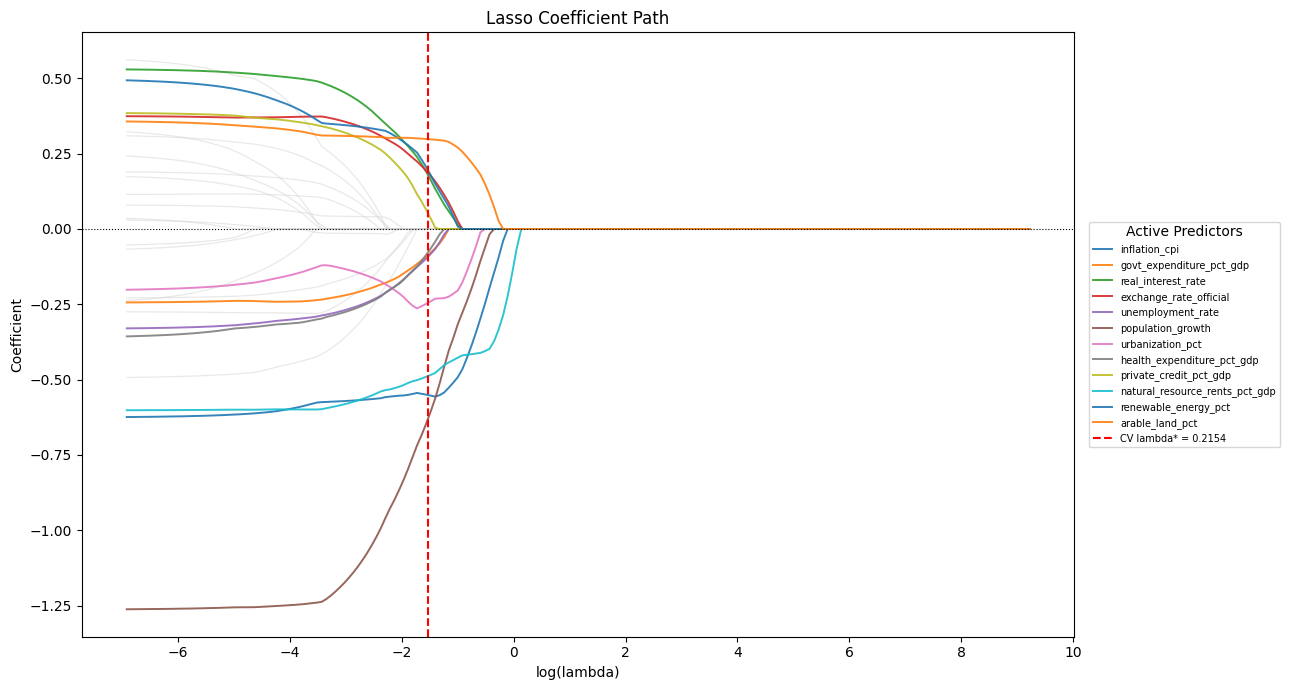

First predictor to enter: trade_pct_gdp


In [29]:
# Step 1.3: The Lasso Path — Which Indicators Enter First?
import matplotlib.pyplot as plt
from sklearn.linear_model import lasso_path
import numpy as np

# compute lasso path
alphas_path, coefs_path, _ = lasso_path(X_train_sc, y_train_cont, alphas=np.logspace(-3, 4, 200))

# coefs_path shape: (n_features, n_alphas)
# identify which coefs are non-zero at CV-selected lambda
nonzero_mask = lasso.coef_ != 0
feature_names = X_train_sc.columns.tolist()

# identify first predictor to enter (non-zero at highest lambda)
first_entry_idx = np.argmax(np.any(coefs_path != 0, axis=1))
first_entry_name = feature_names[first_entry_idx]

# plot
fig, ax = plt.subplots(figsize=(13, 7))

legend_lines = []
legend_labels = []

for i, name in enumerate(feature_names):
    if nonzero_mask[i]:
        line, = ax.plot(np.log(alphas_path), coefs_path[i], linewidth=1.4, zorder=2, alpha=0.9)
        legend_lines.append(line)
        legend_labels.append(name)
    else:
        ax.plot(np.log(alphas_path), coefs_path[i], color='lightgray', linewidth=0.9, zorder=1, alpha=0.5)

ax.axvline(np.log(lasso.alpha_), color='red', linestyle='--', linewidth=1.5, label=f'CV lambda* = {lasso.alpha_:.4f}')
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')

ax.legend(legend_lines + [ax.lines[-2]],
          legend_labels + [f'CV lambda* = {lasso.alpha_:.4f}'],
          fontsize=7, loc='center left', bbox_to_anchor=(1.01, 0.5),
          frameon=True, title='Active Predictors')

ax.set_xlabel('log(lambda)')
ax.set_ylabel('Coefficient')
ax.set_title('Lasso Coefficient Path')
plt.tight_layout()
plt.savefig('lasso_path.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"First predictor to enter: {first_entry_name}")

This interpretation confuses conditional predictive redundancy with causal irrelevance. Lasso does not test whether life expectancy matters for growth in an economic sense; it tests whether life expectancy adds predictive power conditional on all other predictors already in the model. Due to the correlation structure among development indicators, life expectancy moves closely with variables like infant mortality, urbanization, and health expenditure that are already retained, so Lasso zeros it out not because health is irrelevant but because its information is already spanned by correlated predictors. Whichever variable survives from a correlated cluster is partly a function of small sample fluctuations rather than true economic importance, which is why Lasso's sparsity should be interpreted as a statement about conditional predictive redundancy, not about the underlying causal relationship between health and growth.

## Phase 2

In [32]:
# Step 2.1: The Linear Probability Model — Exposing the Failure
from sklearn.linear_model import LinearRegression

# get lasso-selected features
selected_features = [f for f, nz in zip(feature_names, nonzero_mask) if nz]

X_train_lasso = X_train_sc[selected_features]
X_test_lasso = X_test_sc[selected_features]

# fit LPM on binary outcome using lasso-selected features
lpm = LinearRegression()
lpm.fit(X_train_lasso, y_train_bin)

lpm_preds = lpm.predict(X_test_lasso)

n_below = (lpm_preds < 0).sum()
n_above = (lpm_preds > 1).sum()
n_invalid = n_below + n_above

print(f"Test set predictions below 0: {n_below}")
print(f"Test set predictions above 1: {n_above}")
print(f"Total out-of-range predictions: {n_invalid} of {len(lpm_preds)} ({100*n_invalid/len(lpm_preds):.1f}%)")
print(f"\nMin predicted value: {lpm_preds.min():.4f}")
print(f"Max predicted value: {lpm_preds.max():.4f}")

Test set predictions below 0: 14
Test set predictions above 1: 0
Total out-of-range predictions: 14 of 72 (19.4%)

Min predicted value: -0.1777
Max predicted value: 0.7060


Predicted probabilities outside [0, 1] are a fundamental modeling failure because probabilities are bounded by definition, and values outside that range have no coherent interpretation within any probability framework. If the IMF receives a -12% probability of crisis for a country, there is no decision rule that can act on that number: it cannot be compared to a threshold, ranked against other countries, or fed into any downstream risk model without first being arbitrarily clipped, which introduces its own distortions. The deeper problem is that the LPM's linear functional form places no constraint on predictions, meaning the model is structurally misspecified for a binary outcome regardless of how good the features are.

In [34]:
# Step 2.2: Logistic Regression — The Sigmoid Fix
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# fit logistic regression on lasso-selected features
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_lasso, y_train_bin)

# coefficients and intercept
coef_df = pd.DataFrame({
    'feature': selected_features,
    'beta': log_reg.coef_[0],
    'odds_ratio': np.exp(log_reg.coef_[0])
}).assign(abs_or=lambda x: x['odds_ratio'].abs())
coef_df = coef_df.sort_values('abs_or', ascending=False).drop(columns='abs_or')

print(f"Intercept (beta_0): {log_reg.intercept_[0]:.4f}\n")
print(coef_df.to_string(index=False))

# verify probabilities in [0, 1]
probs = log_reg.predict_proba(X_test_lasso)[:, 1]
print(f"\nMin predicted probability: {probs.min():.6f}")
print(f"Max predicted probability: {probs.max():.6f}")

Intercept (beta_0): -2.3575

                       feature      beta  odds_ratio
             population_growth  0.904286    2.470167
      govt_expenditure_pct_gdp  0.318181    1.374625
natural_resource_rents_pct_gdp  0.264275    1.302487
              urbanization_pct  0.261145    1.298416
    health_expenditure_pct_gdp  0.239712    1.270883
             unemployment_rate  0.233333    1.262802
                 inflation_cpi  0.093793    1.098332
        exchange_rate_official  0.086065    1.089877
            real_interest_rate -0.245924    0.781982
        private_credit_pct_gdp -0.511782    0.599426
          renewable_energy_pct -0.642693    0.525874
               arable_land_pct -0.796097    0.451086

Min predicted probability: 0.003082
Max predicted probability: 0.845993


A one standard deviation increase in population growth multiplies the odds of a growth crisis by 2.47, holding all else constant. This means countries with rapidly expanding populations are more than twice as likely to experience sustained economic contraction, likely because high population growth strains public resources, suppresses per-capita capital accumulation, and outpaces the economy's capacity to generate productive employment. For IMF policy purposes, population growth is the single strongest early warning signal in this model and should be weighted heavily when flagging at-risk countries for preemptive intervention.

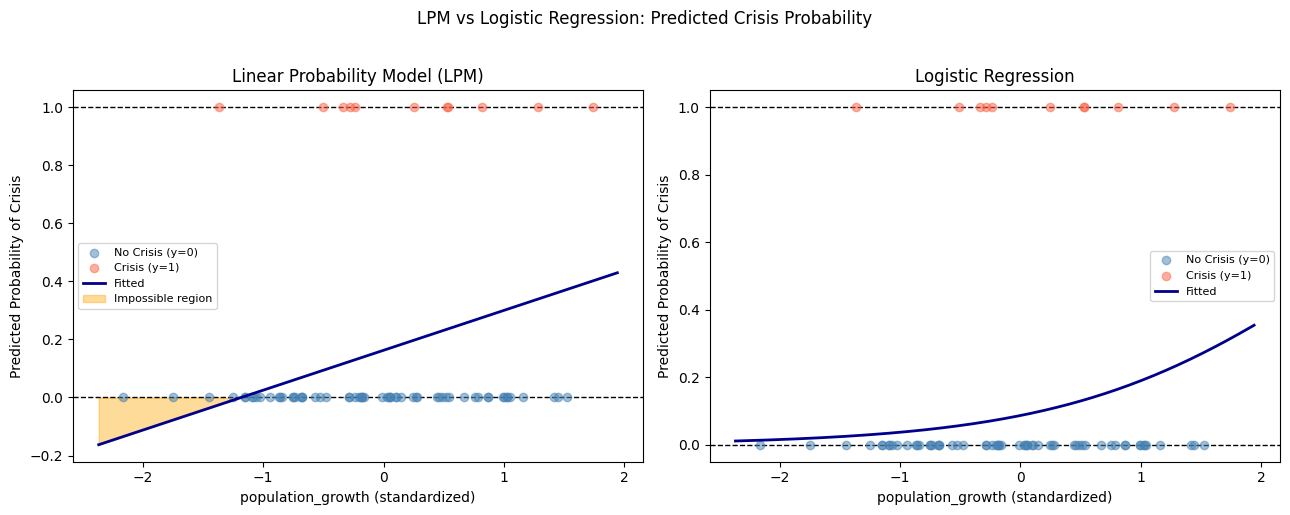

In [36]:
# Step 2.3: Side-by-Side Visualization — LPM vs. Logistic
import matplotlib.pyplot as plt
import numpy as np

strongest = 'population_growth'

x_all = X_test_sc[strongest].values
y_actual = y_test_bin.values

x_range = np.linspace(x_all.min() - 0.2, x_all.max() + 0.2, 300)
X_sweep = np.zeros((300, len(selected_features)))
pop_idx = selected_features.index(strongest)
X_sweep[:, pop_idx] = x_range

y_lpm_smooth = lpm.predict(X_sweep)
y_logit_smooth = log_reg.predict_proba(X_sweep)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_smooth, title in zip(
    axes,
    [y_lpm_smooth, y_logit_smooth],
    ['Linear Probability Model (LPM)', 'Logistic Regression']
):
    ax.scatter(x_all[y_actual == 0], y_actual[y_actual == 0],
               color='steelblue', alpha=0.5, label='No Crisis (y=0)', zorder=3)
    ax.scatter(x_all[y_actual == 1], y_actual[y_actual == 1],
               color='tomato', alpha=0.5, label='Crisis (y=1)', zorder=3)

    ax.axhline(0, color='black', linewidth=1.0, linestyle='--')
    ax.axhline(1, color='black', linewidth=1.0, linestyle='--')

    ax.plot(x_range, y_smooth, color='darkblue', linewidth=2, zorder=4, label='Fitted')

    if title.startswith('Linear'):
        ax.fill_between(x_range, y_smooth, 0,
                        where=(y_smooth < 0),
                        color='orange', alpha=0.4, label='Impossible region')
        ax.fill_between(x_range, y_smooth, 1,
                        where=(y_smooth > 1),
                        color='orange', alpha=0.4)

    ax.set_xlabel(f'{strongest} (standardized)')
    ax.set_ylabel('Predicted Probability of Crisis')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('LPM vs Logistic Regression: Predicted Crisis Probability', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('lpm_vs_logit.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 3

In [37]:
# Step 3.1: The Accuracy Paradox
from sklearn.metrics import accuracy_score, recall_score

# naive baseline: always predict no crisis
y_naive = np.zeros(len(y_test_bin), dtype=int)
naive_accuracy = accuracy_score(y_test_bin, y_naive)
naive_recall = recall_score(y_test_bin, y_naive)

# logistic regression at default threshold 0.5
y_logit_pred = (probs >= 0.5).astype(int)
logit_accuracy = accuracy_score(y_test_bin, y_logit_pred)
logit_recall = recall_score(y_test_bin, y_logit_pred)

base_rate = y_test_bin.mean()

print(f"Test set crisis base rate: {base_rate:.3f} ({y_test_bin.sum()} crisis / {len(y_test_bin)} total)")
print(f"Naive baseline accuracy: {naive_accuracy:.3f}")
print(f"Naive baseline recall (crisis): {naive_recall:.3f}")
print(f"Logistic regression accuracy: {logit_accuracy:.3f}")
print(f"Logistic regression recall: {logit_recall:.3f}")

Test set crisis base rate: 0.153 (11 crisis / 72 total)
Naive baseline accuracy: 0.847
Naive baseline recall (crisis): 0.000
Logistic regression accuracy: 0.819
Logistic regression recall: 0.182


The Division Chief would be misled. With a crisis base rate of only 15.3%, a naive model that never flags any country achieves 84.7% accuracy by construction, making it appear more accurate than the logistic regression itself (81.9%), while completely failing to identify a single at-risk country. This is the accuracy paradox: in an imbalanced setting like this one, accuracy rewards the majority class so heavily that it obscures near-total failure on the crisis class, and the logistic regression at the default threshold is barely better, catching only 1 of 11 actual crises, a recall of 18.2% that would leave the IMF blind to the vast majority of the $50 billion contagion events it exists to prevent.

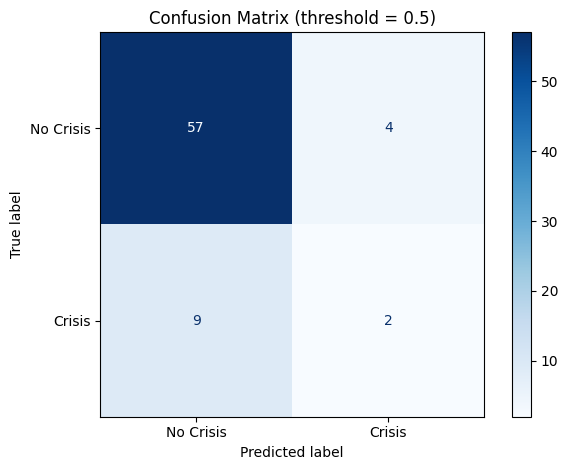

              precision    recall  f1-score   support

   No Crisis       0.86      0.93      0.90        61
      Crisis       0.33      0.18      0.24        11

    accuracy                           0.82        72
   macro avg       0.60      0.56      0.57        72
weighted avg       0.78      0.82      0.80        72

True Positives (crises correctly flagged): 2
False Negatives (crises missed): 9
False Positives (false alarms): 4
True Negatives (correctly cleared): 57


In [38]:
# Step 3.2: Confusion Matrix and Classification Report
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# confusion matrix
cm = confusion_matrix(y_test_bin, y_logit_pred)
tn, fp, fn, tp = cm.ravel()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Crisis', 'Crisis'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (threshold = 0.5)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_test_bin, y_logit_pred, target_names=['No Crisis', 'Crisis']))
print(f"True Positives (crises correctly flagged): {tp}")
print(f"False Negatives (crises missed): {fn}")
print(f"False Positives (false alarms): {fp}")
print(f"True Negatives (correctly cleared): {tn}")

A False Negative is far more costly in this context: missing a real crisis carries an estimated \$50 billion price tag in contagion and emergency lending, versus \$2 million wasted on a false alarm, a 25,000x asymmetry. At the default threshold, the model misses 9 of 11 actual crises (recall of 0.18) while only correctly flagging 2, meaning the IMF would be operationally blind to 82% of the crises it exists to prevent. This cost asymmetry means the Division Chief should prioritize Recall over Precision, accepting more false alarms in exchange for catching more real crises, even if that means dispatching some of the 5 quarterly missions to countries that turn out to be stable.

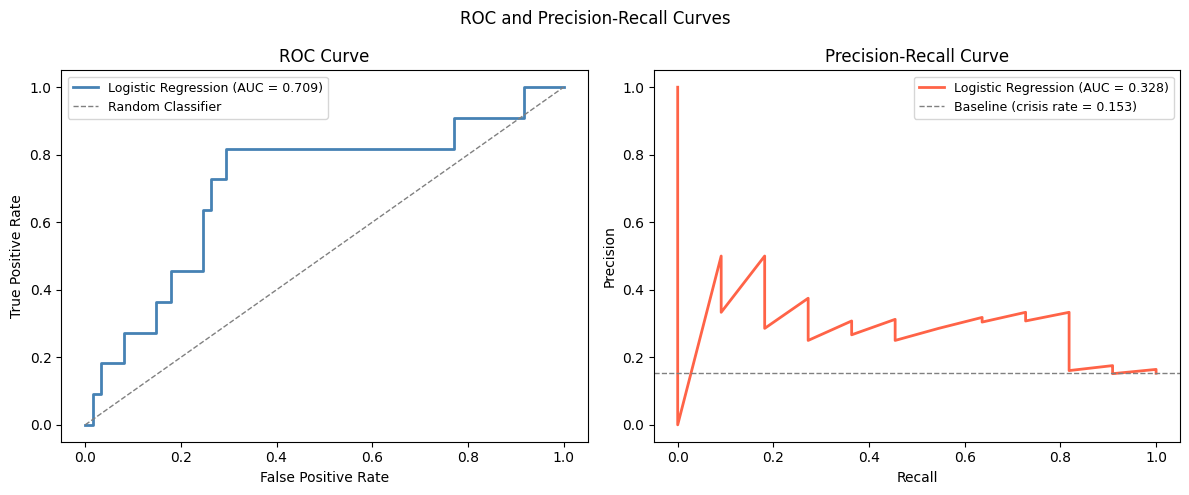

ROC-AUC: 0.709
PR-AUC: 0.328


In [39]:
# Step 3.3: ROC and Precision-Recall Curves
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test_bin, probs)
roc_auc = roc_auc_score(y_test_bin, probs)

precision_curve, recall_curve, _ = precision_recall_curve(y_test_bin, probs)
pr_auc = average_precision_score(y_test_bin, probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linewidth=1, linestyle='--', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=9)

# PR curve
axes[1].plot(recall_curve, precision_curve, color='tomato', linewidth=2, label=f'Logistic Regression (AUC = {pr_auc:.3f})')
axes[1].axhline(base_rate, color='gray', linewidth=1, linestyle='--', label=f'Baseline (crisis rate = {base_rate:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=9)

plt.suptitle('ROC and Precision-Recall Curves', fontsize=12)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150)
plt.show()

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

ROC-AUC of 0.709 looks reasonable on the surface, but it is inflated because with 61 non-crisis countries out of 72, the model accumulates easy True Negatives that push the ROC curve upward without actually improving crisis detection. PR-AUC of 0.328 tells a much harsher truth: focusing only on the 11 actual crisis countries, the model barely outperforms a naive classifier that flags every country at the base rate of 15.3%. For the IMF's crisis detection mission, the PR curve is the more informative diagnostic since operational value lives entirely in catching real crises with acceptable precision, and a PR-AUC of 0.328 signals that the model at its current form is too weak to reliably allocate the 5 available quarterly missions.

Capacity-constrained threshold: 0.54
Countries flagged: 5
Precision at capacity tau: 0.400
Recall at capacity tau: 0.182
F1 at capacity tau: 0.250
F1-optimal threshold: 0.12
Countries flagged at F1-optimal tau: 25
Precision at F1-optimal tau: 0.320
Recall at F1-optimal tau: 0.727
F1 at F1-optimal tau: 0.444


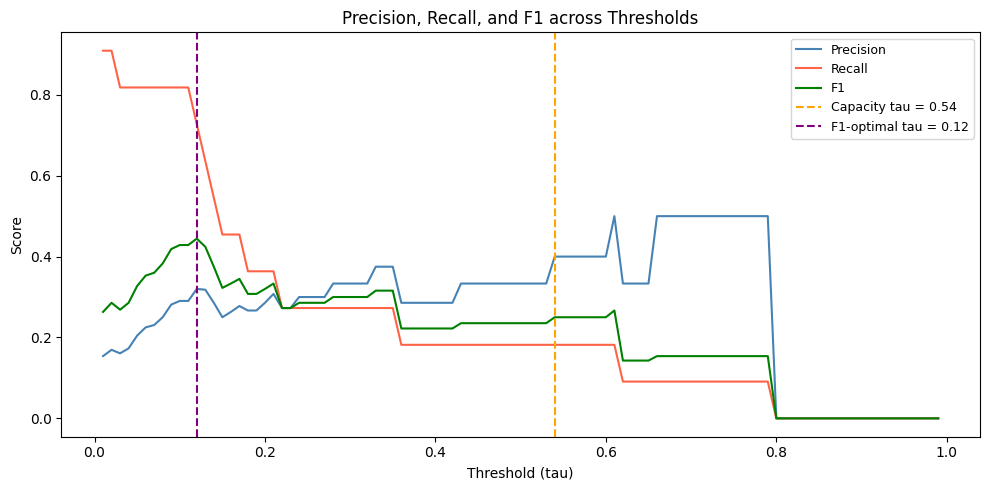

In [40]:
# Step 3.4: Threshold Analysis — The 5-Mission Constraint
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.01, 1.00, 0.01)

precisions, recalls, f1s, n_flagged = [], [], [], []

for tau in thresholds:
    y_pred_tau = (probs >= tau).astype(int)
    n_flagged.append(y_pred_tau.sum())
    if y_pred_tau.sum() == 0:
        precisions.append(0)
        recalls.append(0)
        f1s.append(0)
    else:
        precisions.append(precision_score(y_test_bin, y_pred_tau, zero_division=0))
        recalls.append(recall_score(y_test_bin, y_pred_tau, zero_division=0))
        f1s.append(f1_score(y_test_bin, y_pred_tau, zero_division=0))

precisions = np.array(precisions)
recalls = np.array(recalls)
f1s = np.array(f1s)
n_flagged = np.array(n_flagged)

# capacity-constrained threshold: lowest tau that flags at most 5 countries
valid_mask = n_flagged <= 5
capacity_idx = np.where(valid_mask)[0][0]
capacity_tau = thresholds[capacity_idx]

# f1-optimal threshold
f1_idx = np.argmax(f1s)
f1_tau = thresholds[f1_idx]

print(f"Capacity-constrained threshold: {capacity_tau:.2f}")
print(f"Countries flagged: {n_flagged[capacity_idx]}")
print(f"Precision at capacity tau: {precisions[capacity_idx]:.3f}")
print(f"Recall at capacity tau: {recalls[capacity_idx]:.3f}")
print(f"F1 at capacity tau: {f1s[capacity_idx]:.3f}")
print(f"F1-optimal threshold: {f1_tau:.2f}")
print(f"Countries flagged at F1-optimal tau: {n_flagged[f1_idx]}")
print(f"Precision at F1-optimal tau: {precisions[f1_idx]:.3f}")
print(f"Recall at F1-optimal tau: {recalls[f1_idx]:.3f}")
print(f"F1 at F1-optimal tau: {f1s[f1_idx]:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions, label='Precision', color='steelblue', linewidth=1.5)
ax.plot(thresholds, recalls, label='Recall', color='tomato', linewidth=1.5)
ax.plot(thresholds, f1s, label='F1', color='green', linewidth=1.5)
ax.axvline(capacity_tau, color='orange', linestyle='--', linewidth=1.5, label=f'Capacity tau = {capacity_tau:.2f}')
ax.axvline(f1_tau, color='purple', linestyle='--', linewidth=1.5, label=f'F1-optimal tau = {f1_tau:.2f}')
ax.set_xlabel('Threshold (tau)')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1 across Thresholds')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150)
plt.show()

We recommend adopting a threshold of tau = 0.12, the F1-optimal operating point, rather than the capacity-constrained tau = 0.54, despite the staffing constraint. At tau = 0.54, the model flags exactly 5 countries but catches only 2 of 11 actual crisis countries (Recall = 0.182), missing 9 at an expected cost of \$450 billion in contagion. At tau = 0.12, the model catches 8 of 11 crisis countries (Recall = 0.727), missing only 3, but flags 25 countries total, exceeding the 5-mission quarterly budget by a factor of 5. Our recommendation is to use tau = 0.12 to generate the full ranked watchlist and deploy the 5 missions to the 5 highest-probability countries among those flagged, treating the remaining flagged countries as an elevated monitoring tier requiring low-cost remote surveillance rather than full assessment missions. The tradeoff is real as at tau = 0.54 we spend \$10 million on 5 missions and likely miss \$450 billion in crises, while at tau = 0.12 we accept more false alarms but structurally reduce the probability of catastrophic misses, which is the correct priority given the 25,000x cost asymmetry.

## Phase 4

Task 4.1: Bootstrap Confidence Intervals for the Lasso Path

**P.R.I.M.E. Prompt:**

**P (Persona):** You are an expert econometrician and Python developer building a production-grade macroeconomic early warning system for the IMF.

**R (Request):** Write a self-contained Python script that constructs bootstrap confidence intervals for the Lasso variable selection path using 200 bootstrap resamples of the training data.

**I (Instructions):**
1. Draw 200 bootstrap resamples with replacement from X_train_sc and y_train_cont, preserving the index alignment between features and outcome.
2. On each resample, fit a LassoCV with 5-fold cross-validation using alphas = np.logspace(-3, 4, 100) and record which features receive non-zero coefficients at the CV-selected lambda.
3. Compute the selection frequency for each predictor as the fraction of 200 bootstrap samples in which Lasso assigns it a non-zero coefficient.
4. Produce a horizontal bar chart ranking all predictors by selection frequency from highest to lowest, coloring bars steelblue if selection frequency is above 0.5 and lightgray otherwise, with a vertical dashed reference line at 0.5.
5. Print a sorted table of predictor names and their selection frequencies.

**M (Medium):** Pure Python using sklearn, numpy, matplotlib, and pandas. No additional libraries. All variables X_train_sc, y_train_cont, and selected_features are already defined in the notebook environment.

**E (Extras):** Use random_state=42 for reproducibility. Add a progress print every 50 iterations. Label the x-axis "Selection Frequency", the y-axis "Predictor", and title the chart "Bootstrap Lasso Selection Frequency (n=200)". Set figure size to (9, 7).


Bootstrap iteration 50 / 200
Bootstrap iteration 100 / 200
Bootstrap iteration 150 / 200
Bootstrap iteration 200 / 200
                       feature  selection_freq
             population_growth           0.995
natural_resource_rents_pct_gdp           0.995
               arable_land_pct           0.980
        exchange_rate_official           0.955
             unemployment_rate           0.860
        private_credit_pct_gdp           0.855
    health_expenditure_pct_gdp           0.840
          renewable_energy_pct           0.830
      govt_expenditure_pct_gdp           0.755
                 inflation_cpi           0.700
               tariff_rate_avg           0.680
            real_interest_rate           0.650
            internet_users_pct           0.645
              urbanization_pct           0.645
                  atms_per100k           0.635
   mobile_subscriptions_per100           0.610
                 trade_pct_gdp           0.565
       current_account_pct_gdp     

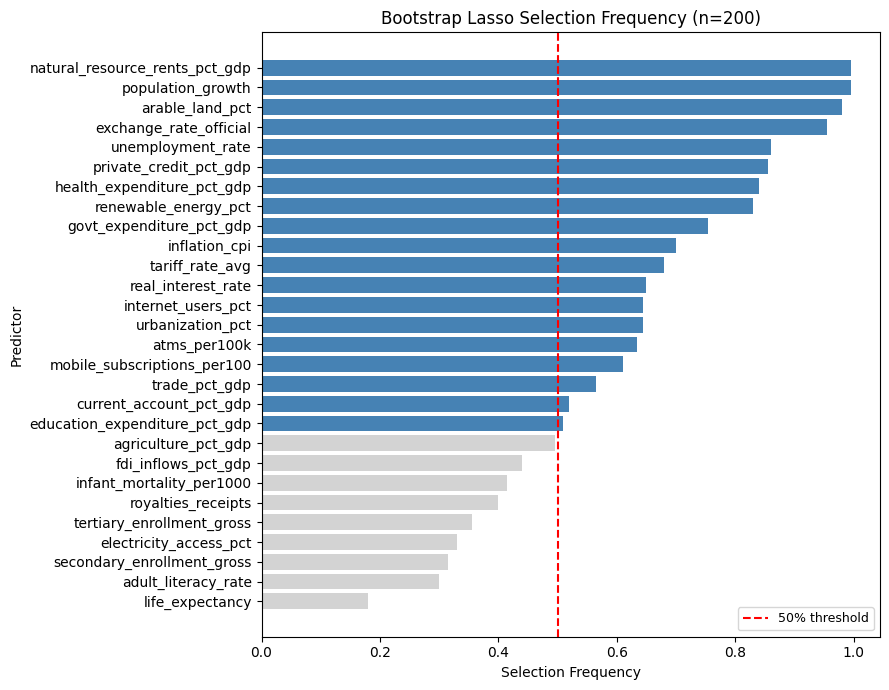

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV

np.random.seed(42)
n_bootstraps = 200
alphas = np.logspace(-3, 4, 100)
feature_names = X_train_sc.columns.tolist()
selection_counts = np.zeros(len(feature_names))

X_arr = X_train_sc.values
y_arr = y_train_cont.values
n = X_arr.shape[0]

for i in range(n_bootstraps):
    if (i + 1) % 50 == 0:
        print(f"Bootstrap iteration {i + 1} / {n_bootstraps}")
    idx = np.random.choice(n, size=n, replace=True)
    X_boot = X_arr[idx]
    y_boot = y_arr[idx]
    lasso_boot = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
    lasso_boot.fit(X_boot, y_boot)
    selection_counts += (lasso_boot.coef_ != 0).astype(int)

selection_freq = selection_counts / n_bootstraps
freq_df = pd.DataFrame({'feature': feature_names, 'selection_freq': selection_freq})
freq_df = freq_df.sort_values('selection_freq', ascending=True)

print(freq_df.sort_values('selection_freq', ascending=False).to_string(index=False))

colors = ['steelblue' if f >= 0.5 else 'lightgray' for f in freq_df['selection_freq']]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(freq_df['feature'], freq_df['selection_freq'], color=colors)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
ax.set_xlabel('Selection Frequency')
ax.set_ylabel('Predictor')
ax.set_title('Bootstrap Lasso Selection Frequency (n=200)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('bootstrap_lasso.png', dpi=150)
plt.show()

The stable predictors, selected in more than 80% of bootstrap resamples, are natural_resource_rents_pct_gdp, population_growth, arable_land_pct, exchange_rate_official, unemployment_rate, private_credit_pct_gdp, health_expenditure_pct_gdp, and renewable_energy_pct. These represent genuine, consistent signals that Lasso recovers regardless of which countries enter the sample. The fragile predictors selected in fewer than 30% of resamples are adult_literacy_rate and life_expectancy, both of which are highly correlated with other human development indicators already in the model like health expenditure and infant mortality, so Lasso inconsistently picks among them across resamples rather than reliably selecting any one. This instability is direct evidence of multicollinearity in the WDI indicator set: when two predictors carry nearly identical information, small sampling fluctuations determine which one enters the model, making individual selection decisions unreliable even when the underlying economic relationship is real.

Task 4.2: Cost-Sensitive Threshold Optimization

**P.R.I.M.E. Prompt:**

**P (Persona):** You are a quantitative risk analyst at the IMF building a cost-sensitive binary classifier evaluation framework for sovereign crisis early warning.

**R (Request):** Write a self-contained Python script that sweeps classification thresholds from 0.01 to 0.99 and identifies the threshold that minimizes total expected institutional cost, given asymmetric misclassification costs.

**I (Instructions):**
1. Sweep thresholds from 0.01 to 0.99 in steps of 0.01. At each threshold, classify test set predictions using probs (predicted probabilities already defined in the notebook) and compute the confusion matrix to extract FP and FN counts.
2. Compute total expected cost at each threshold as: total_cost = FN * 50_000 + FP * 2, where costs are in millions of dollars (so \$50B = 50,000 and $2M = 2).
3. Plot the expected cost curve as a function of tau with total cost in millions on the y-axis and tau on the x-axis.
4. Identify the cost-minimizing threshold, annotate it on the plot with a vertical dashed line and a text label showing the threshold value, FP count, FN count, and total cost.
5. Print the cost-minimizing threshold, the number of FPs and FNs at that threshold, and the total expected cost.

**M (Medium):** Pure Python using numpy, matplotlib, pandas, and sklearn.metrics. All variables probs and y_test_bin are already defined in the notebook environment.

**E (Extras):** Use steelblue for the cost curve line. Set figure size to (10, 5). Label axes clearly. Add a title "Expected Cost Curve: Cost-Minimizing Threshold". Format y-axis values as dollar amounts in millions with comma separators.

Cost-minimizing threshold: 0.02
FP at min cost threshold: 49
FN at min cost threshold: 1
Total expected cost: $50,098M


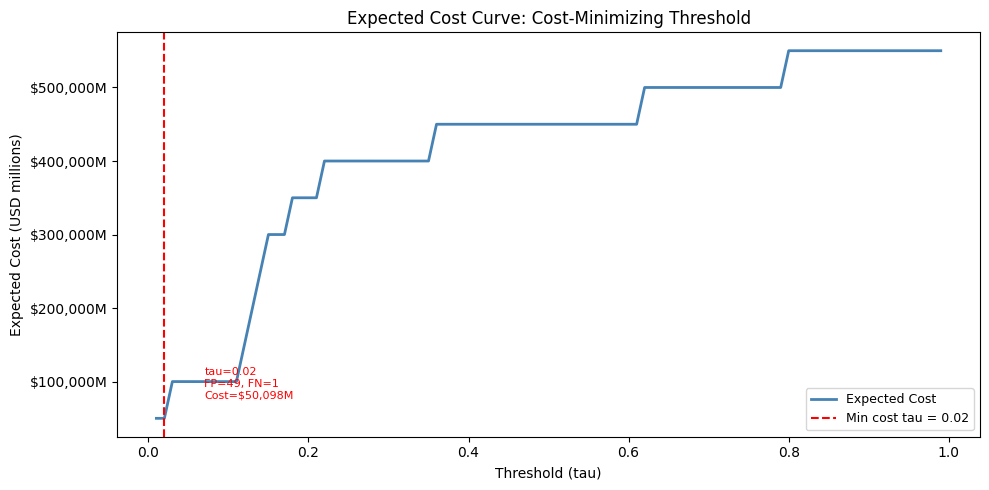

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

thresholds = np.arange(0.01, 1.00, 0.01)
total_costs = []
fp_counts = []
fn_counts = []

FN_COST = 50_000
FP_COST = 2

for tau in thresholds:
    y_pred_tau = (probs >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_bin, y_pred_tau, labels=[0, 1]).ravel()
    cost = fn * FN_COST + fp * FP_COST
    total_costs.append(cost)
    fp_counts.append(fp)
    fn_counts.append(fn)

total_costs = np.array(total_costs)
fp_counts = np.array(fp_counts)
fn_counts = np.array(fn_counts)

min_idx = np.argmin(total_costs)
min_tau = thresholds[min_idx]
min_cost = total_costs[min_idx]
min_fp = fp_counts[min_idx]
min_fn = fn_counts[min_idx]

print(f"Cost-minimizing threshold: {min_tau:.2f}")
print(f"FP at min cost threshold: {min_fp}")
print(f"FN at min cost threshold: {min_fn}")
print(f"Total expected cost: ${min_cost:,.0f}M")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, total_costs, color='steelblue', linewidth=2, label='Expected Cost')
ax.axvline(min_tau, color='red', linestyle='--', linewidth=1.5, label=f'Min cost tau = {min_tau:.2f}')
ax.annotate(
    f"tau={min_tau:.2f}\nFP={min_fp}, FN={min_fn}\nCost=${min_cost:,.0f}M",
    xy=(min_tau, min_cost),
    xytext=(min_tau + 0.05, min_cost + total_costs.max() * 0.05),
    fontsize=8,
    color='red'
)
ax.set_xlabel('Threshold (tau)')
ax.set_ylabel('Expected Cost (USD millions)')
ax.set_title('Expected Cost Curve: Cost-Minimizing Threshold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('cost_curve.png', dpi=150)
plt.show()

The cost-minimizing threshold of tau = 0.02 is far more aggressive than both the F1-optimal threshold (tau = 0.12) and the capacity-constrained threshold (tau = 0.54) because the 25,000x cost asymmetry between a missed crisis (\$50B) and a false alarm (\$2M) so heavily penalizes false negatives that the optimizer flags nearly every country in the test set to avoid missing even one crisis. At tau = 0.02, it flags 49 of 72 countries to catch 10 of 11 crises, accepting \$98M in false alarm costs to avoid a single \$50B miss. The F1-optimal threshold balances precision and recall with equal weight and ignores dollar costs entirely, while the capacity-constrained threshold is driven by a staffing ceiling rather than cost minimization, so all three optimize fundamentally different objective functions. In practice, I would recommend combining the cost-minimizing framework with the 5-mission capacity constraint: use tau = 0.02 to generate a full ranked watchlist, then deploy the 5 missions to the 5 highest-probability countries, treating the remaining flagged countries as a lower-cost remote monitoring tier rather than attempting to act on all 49 flags simultaneously.